## 2D Projectile Motion With Quadratic Drag.
This project simulates the motion of a projectile with quadratic drag in 2D space. In this simulation, we are assuming the acceleration is constant.

We can derive equations of motion (kinematics) starting with the definition of average acceleration and velocity.
$$ \bar{a} = \frac{\Delta v}{\Delta t} = \frac{v_2 - v_1}{t_2 - t_1} \;\text{and}\; \bar{v} = \frac{\Delta x}{\Delta t} = \frac{x_2 - x_1}{t_2 - t_1} $$
We set our initial time $ t_1 $ to be 0 and our $ t_2 $ becomes $ t $, so ${\Delta t} = (t_2 - t_1) = (t_2 - 0) = t_2 = t$.

Putting the above into our equation for average acceleration, we get the following: $a = \frac{v - v_0}{t}$ Solving for $v$, $\boxed{v = v_0 + at}$ , giving us the first kinematics equation.

If we do the same for velocity, we can get the second kinematics equation: $\bar{v} = \frac{\Delta x}{t} \rightarrow \Delta{x} = \bar{v}t \rightarrow \boxed{\Delta{x} = \frac{1}{2}(v_0+v)t}$.

Next, if we substitute $v$ from our first kinematics equation and place it in our second kinematics equation, we can get our third kinematics equation $ \boxed{\Delta{x} = v_0t + \frac{1}{2}at^2}$.

Finally, if we take our first kinematics equation, solve for $t$, and substitute this $t$ into our second kinematics equation and solving for $v^2$, we can get our fourth kinematics equation: $\boxed{v^2 = v_0^2 + 2a\Delta{x}}$.

Our simulation will be relying on our derived equations to model the motion of our projectile. However, there is still one more thing that we need to consider and that is drag. There are three "classical" forms of drag. (Note: There are more forms of drag that range from spinning projectiles to wind-relative, but to keep things short, I'll cover just the three). 
- Linear Drag: $F_d = -bv$.
- Quadratic Drag: $F_d = -cv^2$.
- Mixed Drag: $F_d = -bv - cv^2$.

The above forms of drags are accurate depending on the speed of our projectile, what medium the projectile is traveling through (air vs. oil), and if the projectile stays in one medium or moves through multiple. In the case of projectile motion through the air, we will be using the quadratic form of drag. Having said that, we can finally determine the net force on our object to be: $$\boxed{\sum\vec{F} = m\vec{g} - c{v^2}{\hat{v}}}$$

This equation says that the sum of forces on our object is equal to its mass (m), gravitational acceleration (g, will be -9.81), minus the drag constant of our object multiplied by its velocity squared and the velocity unit vector.

We can break up the net force of our object into its x and y components, using the velocity unit vector, $\hat{v} = \frac{\vec{v}}{||v||}, \;\text{where}\; ||v|| = \sqrt{v_x^2 + v_y^2} = v$

This gives us $a_x = -\frac{c}{m}vv_x$ and $a_y = g_y - \frac{c}{m}vv_y$

Lastly, the value of $c$ that we are using is the lumped drag constant which comes from the formula: $$ \boxed{c = \frac{1}{2} \rho C_d A}  $$

Here, $\rho$ is the density of the medium (air in this case), $C_d$ is the drag coefficient (shape dependent), $A$ is the cross-sectional area of the object. You can use the above formula to calculate c for various objects. The initial parameters I have set is for a baseball (c ~ 0.00086).

Now that the theoretical has been covered. Let's model our projectiles to determine its behavior, both with and without drag.


In [107]:
import numpy as np
import matplotlib.pyplot as plt

def kinematics(v_0=30, angle=45, m=0.15, c=0.00086, y0=10.0):
    g = 9.81 # Acceleration due to Earth's gravity.
    dt = 0.001 # Timestep used to simulate projectile.
    theta = np.radians(angle) # Converting used angles from radians to degrees.

    # Initial Conditions for Projectile with Drag.
    vx = v_0 * np.cos(theta)
    vy = v_0 * np.sin(theta)
    x = 0.0 
    y = y0 

    # Initial Conditions for Projectile without Drag.
    vx_nd = vx
    vy_nd = vy
    x_nd = 0.0
    y_nd = y0

    # Stores the points on trajectory
    x_t, y_t = [x], [y]
    x_t_nd, y_t_nd = [x_nd], [y_nd]
    
    t = 0.0
    while y >= 0 and t < 20:
        # Calculations with Drag.
        v = np.sqrt(vx**2 + vy**2)
        if v > 0:
            # Quadratic drag acceleration: - (c/m) * |v| * v_vector
            ax = -(c/m) * v * vx # X-component of our acceleration which we derived from above.
            ay = -g - (c/m) * v * vy # Y-component of our acceleration which we derived from above.
        else:
            ax = 0
            ay = -g
        
        # Euler Time Step
        vx += ax * dt
        vy += ay * dt
        x += vx * dt
        y += vy * dt

        # Calculations without Drag.
        ax_nd = 0
        ay_nd = -g

        vx_nd += ax_nd * dt
        vy_nd += ay_nd * dt
        x_nd += vx_nd * dt
        y_nd += vy_nd * dt

        
        # Stores both trajectories
        x_t.append(x)
        y_t.append(y)
        x_t_nd.append(x_nd)
        y_t_nd.append(y_nd)
        
        t += dt
    
    # Plots the motion of our projectile.
    plt.figure(figsize=(7, 4))
    plt.plot(x_t, y_t, 'b-', label='With drag')
    plt.plot(x_t_nd, y_t_nd, 'r--', label='No drag')
    plt.xlabel("x (meters)")
    plt.ylabel("y (meters)")
    plt.title(f"Projectile Motion with Quadratic Drag\n"
              f"v₀={v_0} m/s, θ={angle}°, m={m} kg, c={c}")
    plt.grid(True)
    plt.legend()
    plt.show()  
    return x_t, y_t, x_t_nd, y_t_nd

In [108]:
from ipywidgets import interact, FloatSlider

interact(
    kinematics,
    v_0=FloatSlider(min=0, max=1000, step=1, value=30, description='v₀ (m/s)'),
    angle=FloatSlider(min=0, max=90, step=1, value=45, description='Angle (°)'),
    m=FloatSlider(min=0.01, max=10, step=0.01, value=0.15, description='Mass (kg)'),
    c=FloatSlider(min=0.00000, max=0.01, step=0.0001, value=0.00086, readout_format='.6f', description='c'),
    y0=FloatSlider(min=0, max=100, step=1, value=10, description='Initial y (m)')
)

interactive(children=(FloatSlider(value=30.0, description='v₀ (m/s)', max=1000.0, step=1.0), FloatSlider(value…

<function __main__.kinematics(v_0=30, angle=45, m=0.15, c=0.00086, y0=10.0)>

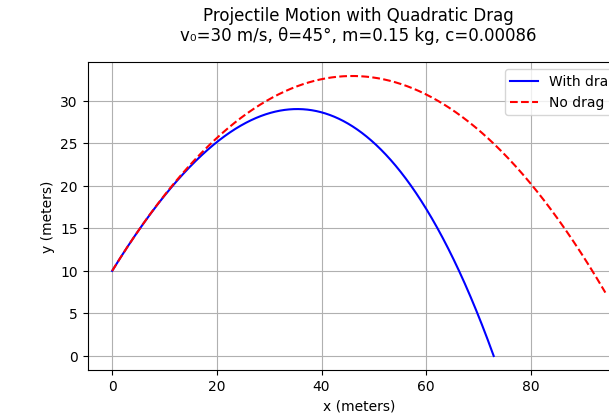

([0.0,
  np.float64(0.021209554764605502),
  np.float64(0.0424154629566723),
  np.float64(0.06361772667308488),
  np.float64(0.08481634800916141),
  np.float64(0.10601132905865503),
  np.float64(0.1272026719137552),
  np.float64(0.14839037866508903),
  np.float64(0.16957445140172267),
  np.float64(0.19075489221116254),
  np.float64(0.21193170317935678),
  np.float64(0.2331048863906965),
  np.float64(0.2542744439280171),
  np.float64(0.27544037787259973),
  np.float64(0.2966026903041724),
  np.float64(0.31776138330091147),
  np.float64(0.33891645893944294),
  np.float64(0.3600679192948437),
  np.float64(0.381215766440643),
  np.float64(0.4023600024488235),
  np.float64(0.42350062938982286),
  np.float64(0.44463764933253497),
  np.float64(0.46577106434431115),
  np.float64(0.48690087649096153),
  np.float64(0.5080270878367564),
  np.float64(0.5291497004444277),
  np.float64(0.5502687163751696),
  np.float64(0.5713841376886408),
  np.float64(0.5924959664429651),
  np.float64(0.61360420469

In [109]:
kinematics()